# KNN Classification Analysis

This notebook loads the preprocessed data, splits it into train/test sets, runs the KNN classifier, and visualizes the results.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from knn_classifier import knn_algorithm, accuracy_metric
from tqdm import tqdm


data = pd.read_csv('spambase_processed_data.csv')
print(f"Loaded {len(data)} samples")

Loaded 4601 samples


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['label']).values
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 3680 samples
Test set: 921 samples


In [4]:
k = 5
print(f"Running with k: {k}")
predictions = knn_algorithm(X_train, y_train, X_test, k)

accuracy = accuracy_metric(y_test, predictions)
print(f"\nAccuracy: {accuracy:.2f}%")
print(f"GT: {y_test[:10]}")
print(f"Predicted: {predictions[:10]}")

Running with k: 5

Accuracy: 90.77%
GT: [1 0 1 0 0 0 1 0 0 0]
Predicted: [1 0 1 0 0 0 1 1 0 0]


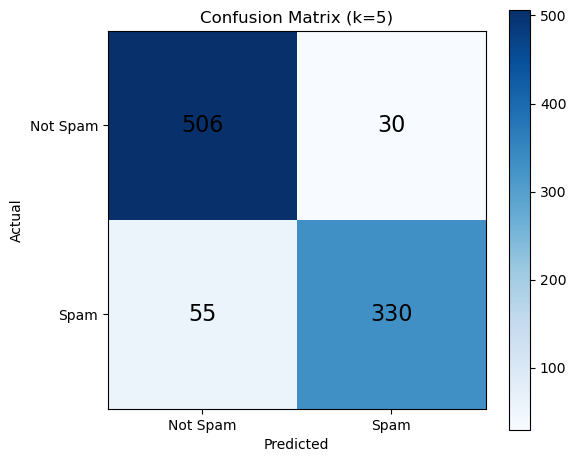

In [5]:
TP = np.sum((y_test == 1) & (predictions == 1))
TN = np.sum((y_test == 0) & (predictions == 0))
FP = np.sum((y_test == 0) & (predictions == 1))
FN = np.sum((y_test == 1) & (predictions == 0))

confusion_matrix = np.array([[TN, FP], [FN, TP]])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion_matrix, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Spam', 'Spam'])
ax.set_yticklabels(['Not Spam', 'Spam'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (k={k})')

for i in range(2):
    for j in range(2):
        ax.text(j, i, confusion_matrix[i, j], ha='center', va='center', color='black', fontsize=16)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Evaluating k values:  12%|█▎        | 1/8 [00:31<03:37, 31.08s/it]

k=1: 91.64%


Evaluating k values:  25%|██▌       | 2/8 [01:02<03:06, 31.06s/it]

k=3: 90.99%


Evaluating k values:  38%|███▊      | 3/8 [01:33<02:35, 31.04s/it]

...

k=11: 88.49%


Evaluating k values:  88%|████████▊ | 7/8 [03:37<00:31, 31.15s/it]

k=15: 88.93%


Evaluating k values: 100%|██████████| 8/8 [04:08<00:00, 31.10s/it]

k=20: 89.36%


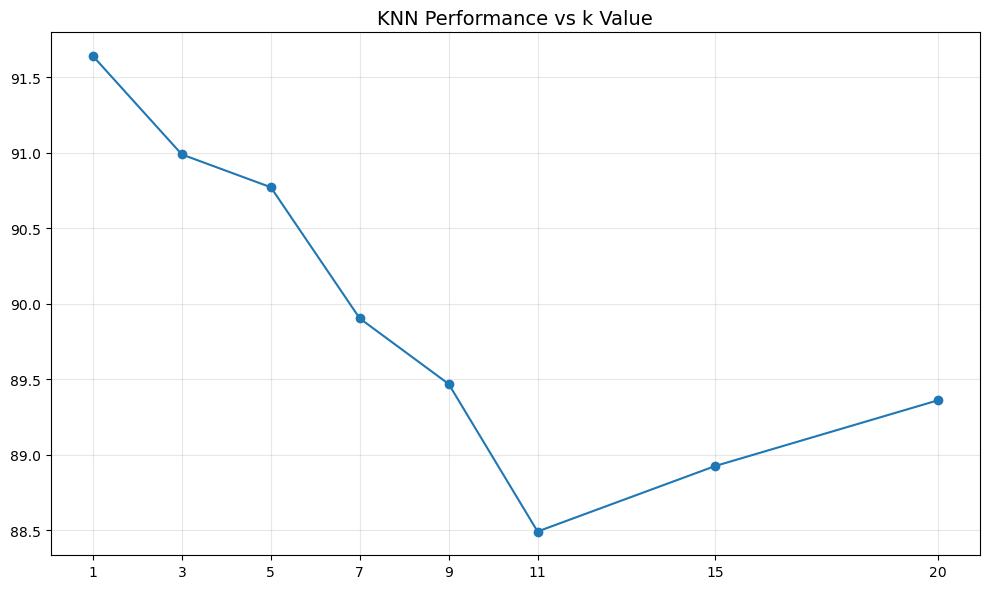

In [7]:
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
accuracies = []

for k in tqdm(k_values, desc="Evaluating k values"):
    preds = knn_algorithm(X_train, y_train, X_test, k)
    acc = accuracy_metric(y_test, preds)
    accuracies.append(acc)
    print(f"k={k}: {acc:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Performance vs k Value', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(accuracies)]

# SHAP Explainability Analysis

Now we use SHAP to understand which features are most important for our KNN classifier predictions.

In [8]:
import shap

In [9]:
from knn_classifier import KNNClassifier

knn_model = KNNClassifier(k=best_k)
knn_model.fit(X_train, y_train)

test_predictions = knn_model.predict(X_test)
test_accuracy = accuracy_metric(y_test, test_predictions)
print(f"Model accuracy with k={best_k}: {test_accuracy}%")

sample_probas = knn_model.predict_proba(X_test[:5])
print(f"\nSample probability predictions:")
print(sample_probas)

Model accuracy with k=1: 91.63952225841476%

Sample probability predictions:
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


In [10]:
# KernelExplainer is slow, so we minimize background samples
background_data = shap.kmeans(X_train, 5)  # get 5 samples
explainer = shap.KernelExplainer(model=lambda x: knn_model.predict_proba(x)[:, 1],  data=background_data)

In [11]:
# Calculate SHAP values for a subset of test data
# Using only 3 samples for faster computation (KernelExplainer is very slow)
n_samples = 3
X_explain = X_test[:n_samples]
print(f"Calculating SHAP values for {n_samples} test samples...")

shap_values = explainer.shap_values(X_explain, nsamples=100)  # Limit kernel samples
print(f"Shape of SHAP values: {shap_values.shape}")

Calculating SHAP values for 3 test samples...


  0%|          | 0/3 [00:00<?, ?it/s]

Shape of SHAP values: (3, 57)


In [12]:
feature_names = data.drop(columns=['label']).columns.tolist()
print(f"Number of features: {len(feature_names)}")
print(f"Feature names (first 10): {feature_names[:10]}")

Number of features: 57
Feature names (first 10): ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail']


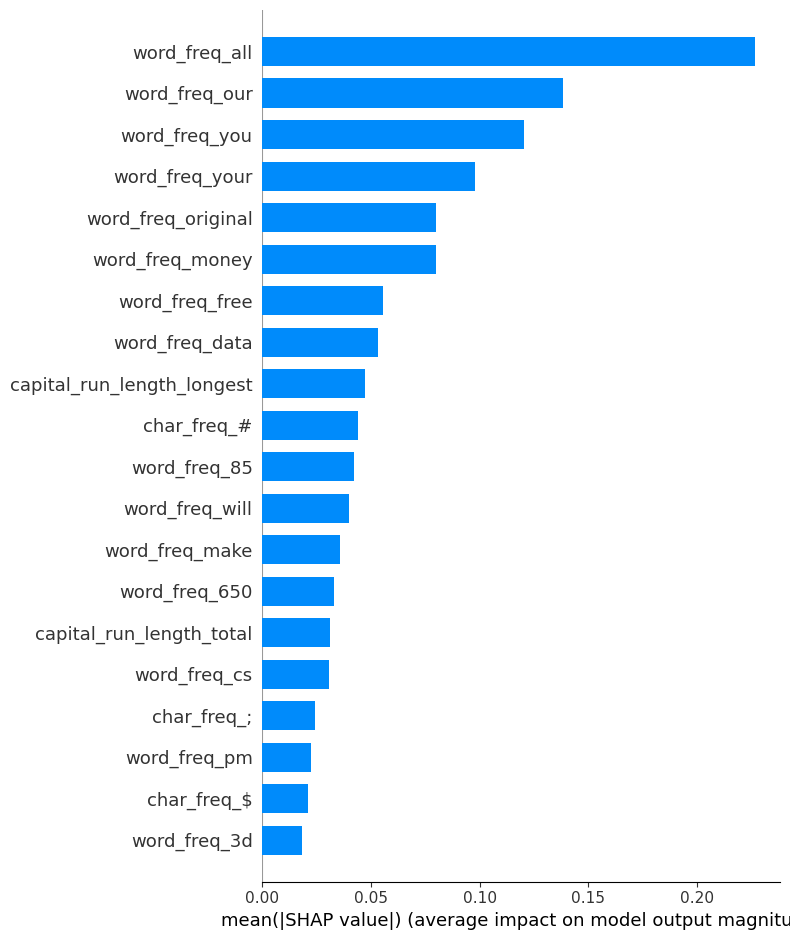

In [13]:
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type="bar")

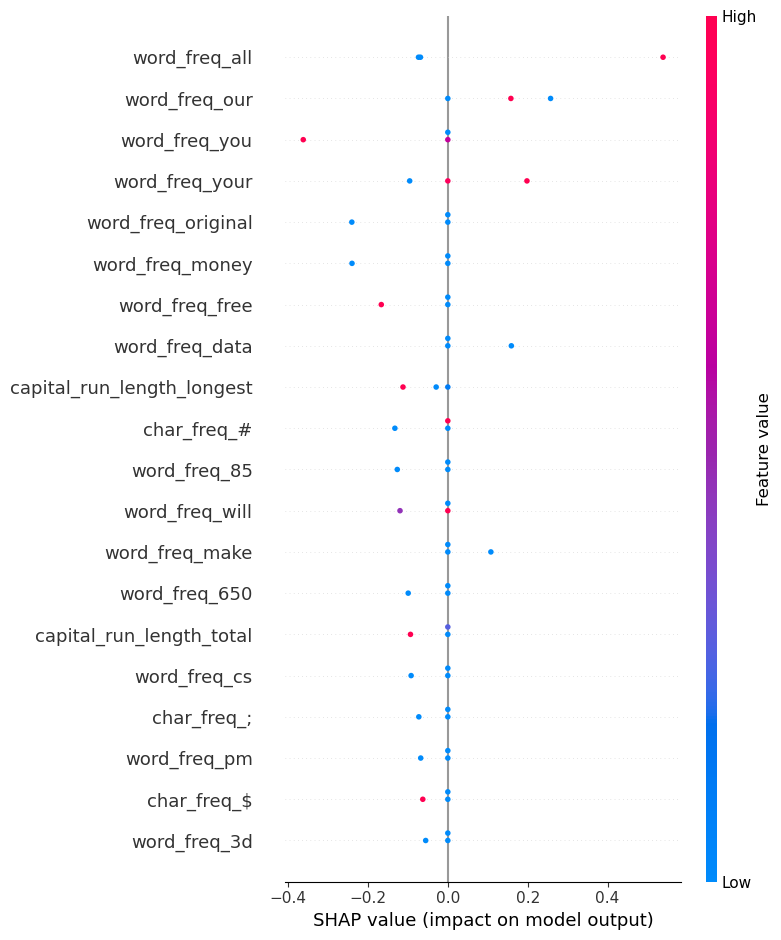

In [14]:
shap.summary_plot(shap_values, X_explain, feature_names=feature_names)

Explaining prediction for test sample 0
Actual label: 1
Predicted label: 1
Predicted probability of spam: 1.000


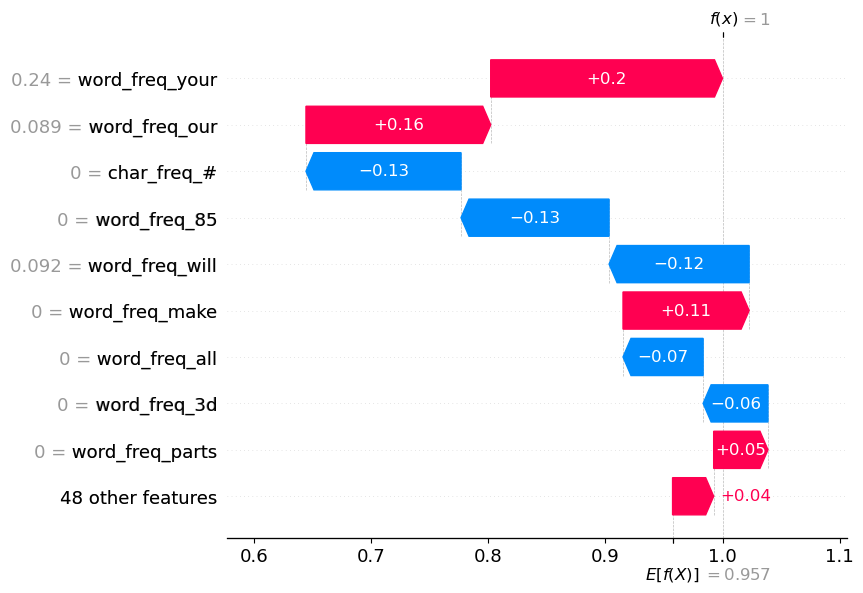

In [15]:
sample_idx = 0
print(f"Explaining prediction for test sample {sample_idx}")
print(f"Actual label: {y_test[sample_idx]}")
print(f"Predicted label: {test_predictions[sample_idx]}")
print(f"Predicted probability of spam: {knn_model.predict_proba(X_test[sample_idx:sample_idx+1])[0, 1]:.3f}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_explain[sample_idx],
        feature_names=feature_names
    )
)

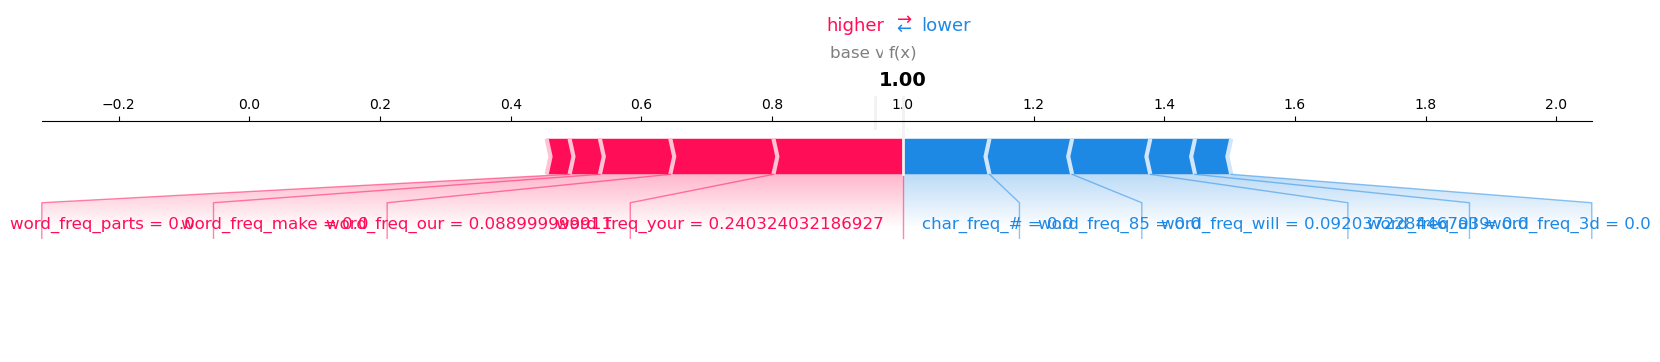

<Figure size 640x480 with 0 Axes>

In [16]:
shap.force_plot(explainer.expected_value,shap_values[sample_idx],X_explain[sample_idx],feature_names=feature_names,matplotlib=True)
plt.tight_layout()
plt.show()


Waterfall plot for SPAM email:


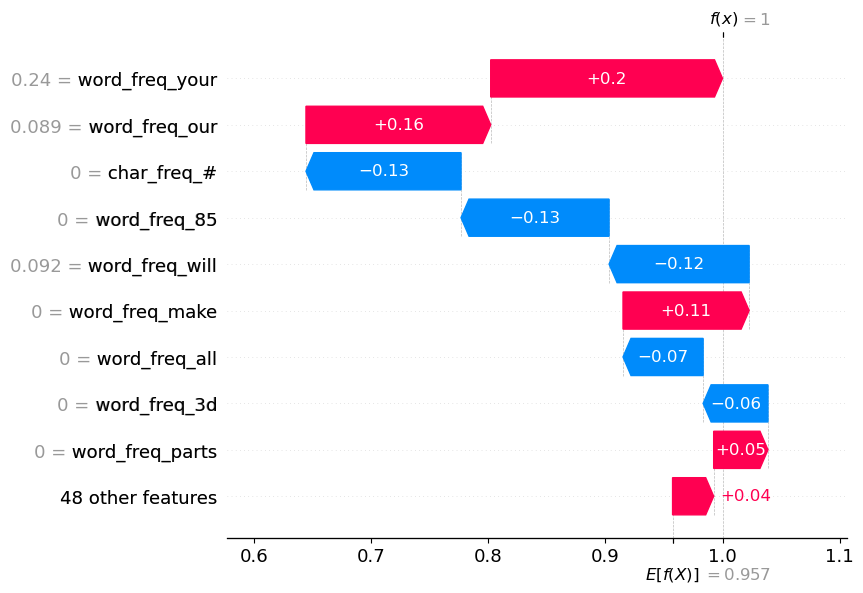

<Figure size 640x480 with 0 Axes>


Waterfall plot for NON-SPAM email:


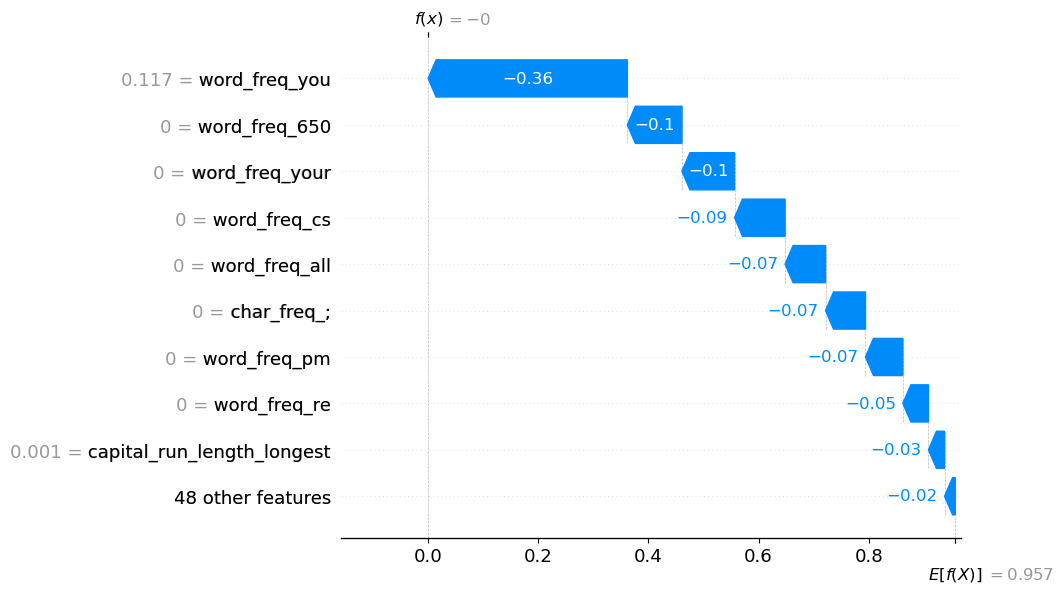

<Figure size 640x480 with 0 Axes>

In [19]:
spam_indices = [i for i in range(len(y_test[:n_samples])) if y_test[i] == 1 and test_predictions[i] == 1]
non_spam_indices = [i for i in range(len(y_test[:n_samples])) if y_test[i] == 0 and test_predictions[i] == 0]

if len(spam_indices) > 0 and len(non_spam_indices) > 0:
    spam_idx = spam_indices[0]
    non_spam_idx = non_spam_indices[0]
    
    print("\nWaterfall plot for SPAM email:")
    shap.waterfall_plot(
        shap.Explanation(values=shap_values[spam_idx],base_values=explainer.expected_value,data=X_explain[spam_idx],feature_names=feature_names))
    plt.tight_layout()
    plt.show()
    
    print("\nWaterfall plot for NON-SPAM email:")
    shap.waterfall_plot(
        shap.Explanation(values=shap_values[non_spam_idx],base_values=explainer.expected_value, data=X_explain[non_spam_idx],feature_names=feature_names))
    plt.tight_layout()
    plt.show()

## Key Insights from SHAP Analysis

The SHAP explainability analysis provides several key insights:

1. **Feature Importance**: The bar plot shows which features have the strongest overall impact on spam classification across all predictions.

2. **Feature Effects**: The detailed summary plot reveals:
   - **Red dots** indicate high feature values
   - **Blue dots** indicate low feature values
   - Position on x-axis shows whether the feature pushes prediction towards spam (positive) or non-spam (negative)

3. **Individual Predictions**: Waterfall and force plots break down how each feature contributes to specific email classifications, showing which features pushed the prediction toward spam or non-spam.

This explainability helps us understand:
- Which email characteristics are most indicative of spam
- How the KNN model makes decisions
- Why specific emails are classified as spam or not spam
- Which features to focus on for improving spam detection